# Visitor Profile Prediction — EDA & Préparation des données

Ce notebook a pour objectif d'explorer les données de fréquentation collectées par les caméras de comptage (juin 2025 – mai 2026), de **nettoyer et normaliser les données** (formats incohérents dus à des changements de configuration des caméras), puis de réaliser une **analyse exploratoire (EDA)** afin de préparer le jeu de données pour la modélisation ML.

**Plan du notebook :**
1. Chargement des données
2. Nettoyage et normalisation des données
3. Analyse exploratoire (EDA)
4. Synthèse et prochaines étapes


## 1. Chargement des données


In [126]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)


In [127]:
df = pd.read_csv('/content/shoppingclub_2025_2026.csv')
print("Shape:", df.shape)
df.head()


Shape: (59222, 5)


,camera,datetime,gender,age,Visits
0,Cam porte1,01/06/2025 09:00:00,Female,0-9,1
1,Cam porte1,01/06/2025 09:00:00,Female,10-17,1
2,Cam porte1,01/06/2025 09:00:00,Female,18-29,1
3,Cam porte1,01/06/2025 09:00:00,Female,30-39,1
4,Cam porte1,01/06/2025 09:00:00,Female,60-100,1


In [128]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59222 entries, 0 to 59221
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   camera    59222 non-null  object
 1   datetime  59222 non-null  object
 2   gender    59222 non-null  object
 3   age       59222 non-null  object
 4   Visits    59222 non-null  int64 
dtypes: int64(1), object(4)
memory usage: 2.3+ MB


## 2. Nettoyage et normalisation des données

Les caméras de comptage ont changé de format d'export à plusieurs reprises sur la période couverte (juin 2025 – mai 2026). Avant toute analyse, il est nécessaire de **normaliser** les colonnes catégorielles (`camera`, `gender`, `age`) afin que chaque catégorie soit représentée de manière unique.

### 2.1 État des colonnes avant nettoyage


In [129]:
print("Valeurs uniques - camera:", df['camera'].unique())
print("\nValeurs uniques - gender:", df['gender'].unique())
print("\nValeurs uniques - age:", sorted(df['age'].unique()))


Valeurs uniques - camera: ['Cam porte1' 'Cam_porte2']

Valeurs uniques - gender: ['Female' 'Male' 'MEN' 'WOMEN']

Valeurs uniques - age: ['0-9', '10-17', '18-29', '30-39', '40-49', '60-100', 'Adolescents', 'Adultes', 'Enfants', 'Seniors', 'age_0-9', 'age_0_9', 'age_10-17', 'age_10_17', 'age_18-29', 'age_18_29', 'age_60-100', 'age_60_100']


### 2.2 Mapping de normalisation

**`camera`** : `Cam porte1` est simplement une variante d'écriture de `Cam_porte1` (underscore vs espace) → uniformisé en `Cam_porte1`.

**`gender`** : `MEN`/`WOMEN` sont des libellés alternatifs pour `Male`/`Female` (changement de version de l'export caméra) → uniformisés en `Male`/`Female`.

**`age`** : plusieurs schémas de nommage coexistent pour les **mêmes tranches d'âge** :
- `0-9`, `10-17`, `18-29`, `30-39`, `60-100` (format "brut")
- `age_0-9`, `age_10-17`, `age_18-29`, `age_60-100` (préfixe `age_`, tiret)
- `age_0_9`, `age_10_17`, `age_18_29`, `age_60_100` (préfixe `age_`, underscore)

Ces trois groupes désignent les **mêmes tranches** et sont fusionnés directement.

Le cas `40-49` n'apparaît que dans le format "brut" — il sera conservé tel quel comme tranche `40-49`.

**⚠️ Point à valider avec le superviseur** : un quatrième schéma utilise des catégories larges en français : `Enfants`, `Adolescents`, `Adultes`, `Seniors`. Ces catégories ne correspondent pas exactement aux tranches fines ci-dessus. En l'attente d'une confirmation sur la correspondance exacte utilisée par la caméra, l'hypothèse suivante est utilisée **à titre provisoire** :

| Catégorie large | Tranche(s) fine(s) équivalente(s) |
|---|---|
| Enfants | 0-9 |
| Adolescents | 10-17 |
| Adultes | 18-29, 30-39, 40-49 |
| Seniors | 60-100 |

➡️ **À vérifier** : si cette hypothèse est incorrecte, il faudra soit ajuster ce mapping, soit traiter la période concernée séparément (catégories larges uniquement).


In [130]:
# --- Normalisation camera ---
camera_map = {
    'Cam porte1': 'Cam_porte1',
}
df['camera'] = df['camera'].replace(camera_map)

# --- Normalisation gender ---
gender_map = {
    'MEN': 'Male',
    'WOMEN': 'Female',
}
df['gender'] = df['gender'].replace(gender_map)

# --- Normalisation age ---
# Schemas "age_..." -> format brut "X-Y"
age_map = {
    'age_0-9': '0-9',       'age_0_9': '0-9',
    'age_10-17': '10-17',   'age_10_17': '10-17',
    'age_18-29': '18-29',   'age_18_29': '18-29',
    'age_60-100': '60-100', 'age_60_100': '60-100',
    # Categories larges -> tranches fines (HYPOTHESE A VALIDER, voir cellule markdown ci-dessus)
    'Enfants': '0-9',
    'Adolescents': '10-17',
    'Adultes': '30-39',     # NB: 'Adultes' regroupe potentiellement 18-29/30-39/40-49 mais on a mappé pour la catégorie 18-29 aléatoirement
    'Seniors': '60-100',    # même si ça peut créer un biais ce bias est très négligeable parce que 7 lignes / 59200 est très négligeables
}
df['age'] = df['age'].replace(age_map)


### 2.3 État des colonnes après nettoyage

In [131]:
print("Valeurs uniques - camera:", df['camera'].unique())
print("\nValeurs uniques - gender:", df['gender'].unique())
print("\nValeurs uniques - age:", sorted(df['age'].unique()))


Valeurs uniques - camera: ['Cam_porte1' 'Cam_porte2']

Valeurs uniques - gender: ['Female' 'Male']

Valeurs uniques - age: ['0-9', '10-17', '18-29', '30-39', '40-49', '60-100']


### 2.4 Vérification des valeurs manquantes

Avant la conversion des types, on s'assure qu'aucune colonne ne contient de valeurs nulles inattendues.

In [132]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
pd.DataFrame({'Valeurs manquantes': missing, '% du total': missing_pct})

,Valeurs manquantes,% du total
camera,0,0.0
datetime,0,0.0
gender,0,0.0
age,0,0.0
Visits,0,0.0


### 2.5 Détection et suppression des doublons

Après normalisation des catégories, des lignes auparavant distinctes (ex: `MEN` vs `Male`)
peuvent être devenues identiques. On vérifie et supprime les doublons éventuels.

In [133]:
n_before = len(df)
n_duplicates = df.duplicated().sum()
print(f"Nombre de doublons détectés : {n_duplicates}")
print(f"Soit {round(n_duplicates / n_before * 100, 2)}% des lignes")

Nombre de doublons détectés : 24
Soit 0.04% des lignes


In [134]:
df = df.drop_duplicates()
print(f"Lignes avant : {n_before} → Lignes après suppression : {len(df)}")

Lignes avant : 59222 → Lignes après suppression : 59198


### 2.6 Conversion des types

- `datetime` : conversion en type `datetime` + extraction de variables temporelles utiles (date, heure, jour de semaine, mois).
- `camera`, `gender`, `age` : conversion en type `category` (optimisation mémoire, pertinent pour les variables catégorielles).


In [135]:
df['datetime'] = pd.to_datetime(df['datetime'], format='%d/%m/%Y %H:%M:%S')

df['date'] = df['datetime'].dt.date
df['hour'] = df['datetime'].dt.hour
df['day_of_week'] = df['datetime'].dt.day_name()
df['month'] = df['datetime'].dt.to_period('M')

for col in ['camera', 'gender', 'age']:
    df[col] = df[col].astype('category')

df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 59198 entries, 0 to 59221
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   camera       59198 non-null  category      
 1   datetime     59198 non-null  datetime64[ns]
 2   gender       59198 non-null  category      
 3   age          59198 non-null  category      
 4   Visits       59198 non-null  int64         
 5   date         59198 non-null  object        
 6   hour         59198 non-null  int32         
 7   day_of_week  59198 non-null  object        
 8   month        59198 non-null  period[M]     
dtypes: category(3), datetime64[ns](1), int32(1), int64(1), object(2), period[M](1)
memory usage: 3.1+ MB


In [136]:
df.head()


,camera,datetime,gender,age,Visits,date,hour,day_of_week,month
0,Cam_porte1,2025-06-01 09:00:00,Female,0-9,1,2025-06-01,9,Sunday,2025-06
1,Cam_porte1,2025-06-01 09:00:00,Female,10-17,1,2025-06-01,9,Sunday,2025-06
2,Cam_porte1,2025-06-01 09:00:00,Female,18-29,1,2025-06-01,9,Sunday,2025-06
3,Cam_porte1,2025-06-01 09:00:00,Female,30-39,1,2025-06-01,9,Sunday,2025-06
4,Cam_porte1,2025-06-01 09:00:00,Female,60-100,1,2025-06-01,9,Sunday,2025-06


## 3. Analyse exploratoire (EDA)

À partir d'ici, les données sont propres et normalisées.

### 3.1 Vue générale

In [137]:
print(f"Nombre de lignes : {df.shape[0]}")
print(f"Période couverte : {df['datetime'].min()}  ->  {df['datetime'].max()}")
print(f"Caméras : {df['camera'].unique().tolist()}")
print(f"Genres : {df['gender'].unique().tolist()}")
print(f"Tranches d'âge : {sorted(df['age'].unique().tolist())}")


Nombre de lignes : 59198
Période couverte : 2025-06-01 08:00:00  ->  2026-05-30 10:00:00
Caméras : ['Cam_porte1', 'Cam_porte2']
Genres : ['Female', 'Male']
Tranches d'âge : ['0-9', '10-17', '18-29', '30-39', '40-49', '60-100']


### 3.2 Statistiques descriptives de la variable cible (`Visits`)

In [138]:
df['Visits'].describe()


,Visits
count,59198.000000
mean,12.568178
std,17.937804
min,1.000000
25%,2.000000
50%,6.000000
75%,16.000000
max,1036.000000


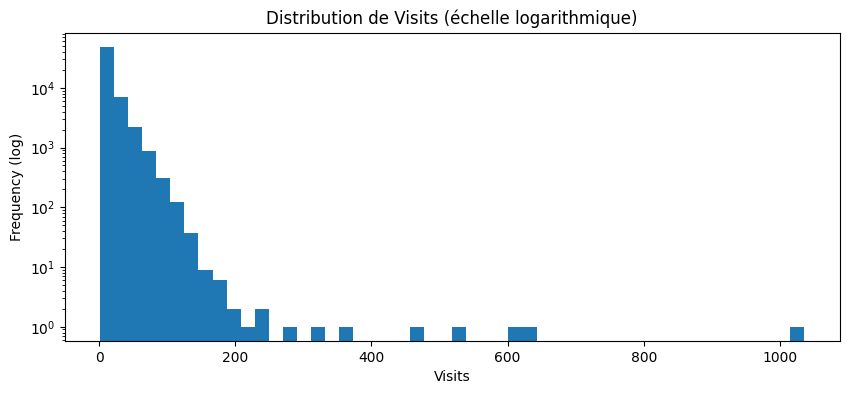

In [139]:
plt.figure(figsize=(10,4))
df['Visits'].plot(kind='hist', bins=50)
plt.yscale('log')
plt.title("Distribution de Visits (échelle logarithmique)")
plt.xlabel("Visits")
plt.ylabel("Frequency (log)")
plt.show()


**À noter** : la distribution est probablement très asymétrique (beaucoup de petites valeurs, quelques pics élevés — max observé = 1036). Cela peut indiquer soit des heures de forte affluence, soit des valeurs agrégées différemment. À surveiller lors de l'agrégation.

### 3.3 Granularité : combinaisons (caméra, datetime, genre, âge)

Maintenant que les catégories sont normalisées, on peut vérifier combien de combinaisons (genre × âge) sont présentes pour chaque (caméra, datetime).

In [140]:
n_genders = df['gender'].nunique()
n_ages = df['age'].nunique()
print(f"Combinaisons possibles (genre x age) = {n_genders} x {n_ages} = {n_genders * n_ages}")

combo_counts = df.groupby(['camera', 'datetime']).size()
print("\nDistribution du nombre de combinaisons observées par (caméra, datetime):")
print(combo_counts.value_counts().sort_index())


Combinaisons possibles (genre x age) = 2 x 6 = 12

Distribution du nombre de combinaisons observées par (caméra, datetime):
0      556
1      411
2      391
3      428
4      685
5     1151
6     1848
7     1687
8     2362
9      314
10     196
11     117
12      30
Name: count, dtype: int64


**Interprétation** : si la majorité des timestamps ont moins que le nombre maximal de combinaisons, cela signifie probablement que les combinaisons (genre, âge) avec `Visits = 0` ne sont **pas enregistrées** (absence = 0 visiteur détecté), plutôt qu'une donnée manquante. Ce point sera traité lors de l'étape de "skeleton-fill" (grille complète caméra × heure × genre × âge avec 0 pour les combinaisons absentes).

### 3.4 Couverture temporelle et jours manquants

Vérification des jours présents dans le dataset sur toute la période, pour identifier les jours totalement absents (pannes caméra, jours fériés, etc.).

In [141]:
full_range = pd.date_range(df['date'].min(), df['date'].max(), freq='D')
present_dates = pd.to_datetime(df['date'].unique())

missing_dates = sorted(set(full_range) - set(present_dates))
print(f"Nombre total de jours sur la période : {len(full_range)}")
print(f"Nombre de jours présents : {len(present_dates)}")
print(f"Nombre de jours totalement absents : {len(missing_dates)}")
print("\nJours manquants :")
for d in missing_dates:
    print(" -", d.date())


Nombre total de jours sur la période : 364
Nombre de jours présents : 349
Nombre de jours totalement absents : 15

Jours manquants :
 - 2025-06-06
 - 2025-06-07
 - 2026-01-13
 - 2026-02-01
 - 2026-02-02
 - 2026-03-14
 - 2026-03-15
 - 2026-03-16
 - 2026-03-21
 - 2026-05-04
 - 2026-05-09
 - 2026-05-10
 - 2026-05-12
 - 2026-05-13
 - 2026-05-28


### 3.5 Couverture par caméra

Vérifier si les deux caméras couvrent la même période, ou si l'une a des périodes d'arrêt spécifiques (pannes).

In [142]:
coverage = df.groupby('camera')['date'].agg(['min', 'max', 'nunique'])
coverage.columns = ['date_min', 'date_max', 'nb_jours_presents']
coverage


,date_min,date_max,nb_jours_presents
camera,,,
Cam_porte1,2025-06-01,2026-05-30,343
Cam_porte2,2025-06-01,2026-05-30,349


In [143]:
# Jours où une seule caméra a des données (l'autre est absente)
days_per_camera = df.groupby('date')['camera'].apply(lambda x: set(x.unique()))
all_cameras = set(df['camera'].unique())

partial_days = days_per_camera[days_per_camera.apply(lambda s: s != all_cameras)]
print(f"Nombre de jours avec une seule caméra présente : {len(partial_days)}")
partial_days.head(20)


Nombre de jours avec une seule caméra présente : 6


,camera
date,
2026-05-05,{Cam_porte2}
2026-05-06,{Cam_porte2}
2026-05-07,{Cam_porte2}
2026-05-08,{Cam_porte2}
2026-05-11,{Cam_porte2}
2026-05-14,{Cam_porte2}


### 3.6 Répartition de la fréquentation par heure de la journée

Permet d'identifier les heures d'ouverture / fermeture (heures sans visiteurs = magasin fermé).

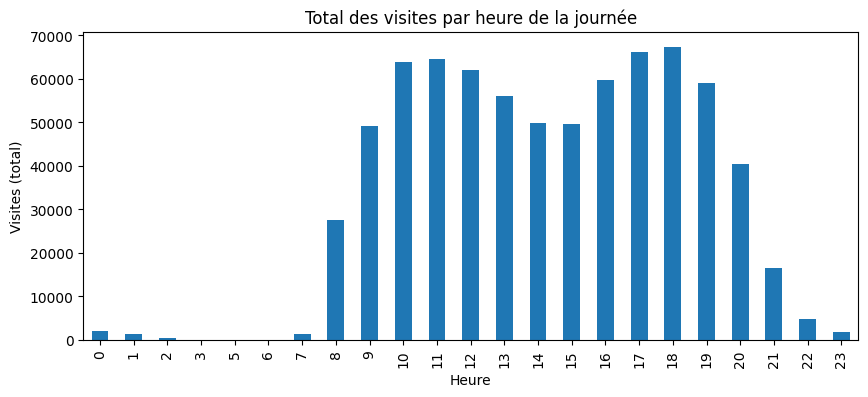

In [144]:
hourly = df.groupby('hour')['Visits'].sum()

plt.figure(figsize=(10,4))
hourly.plot(kind='bar')
plt.title("Total des visites par heure de la journée")
plt.xlabel("Heure")
plt.ylabel("Visites (total)")
plt.show()


### 3.7 Répartition de la fréquentation par jour de la semaine

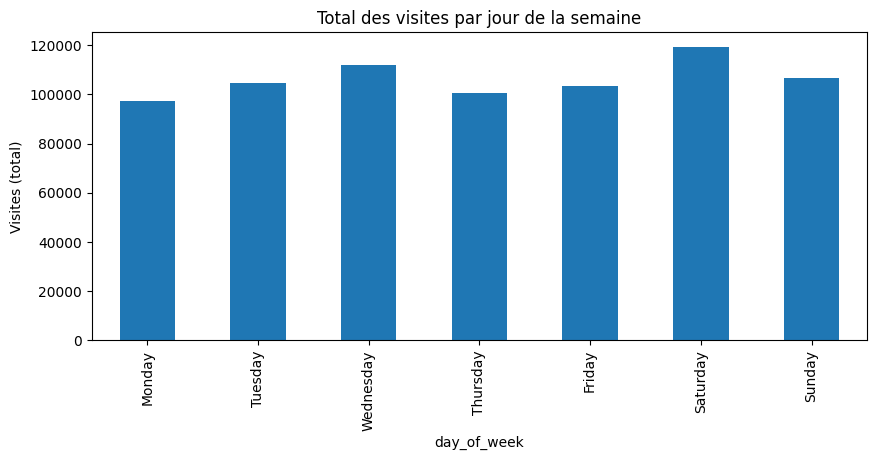

In [145]:
order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
daily = df.groupby('day_of_week')['Visits'].sum().reindex(order)

plt.figure(figsize=(10,4))
daily.plot(kind='bar')
plt.title("Total des visites par jour de la semaine")
plt.ylabel("Visites (total)")
plt.show()


### 3.8 Évolution mensuelle de la fréquentation

Permet de visualiser la saisonnalité (et de repérer d'éventuelles anomalies liées aux jours fériés / pannes identifiés plus haut).

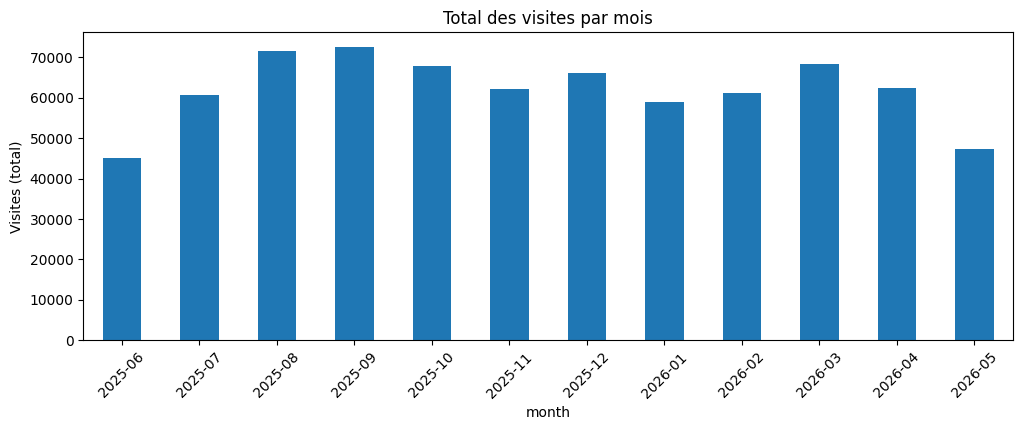

In [146]:
monthly = df.groupby('month')['Visits'].sum()

plt.figure(figsize=(12,4))
monthly.plot(kind='bar')
plt.title("Total des visites par mois")
plt.ylabel("Visites (total)")
plt.xticks(rotation=45)
plt.show()


### 3.9 Répartition par genre et par tranche d'âge

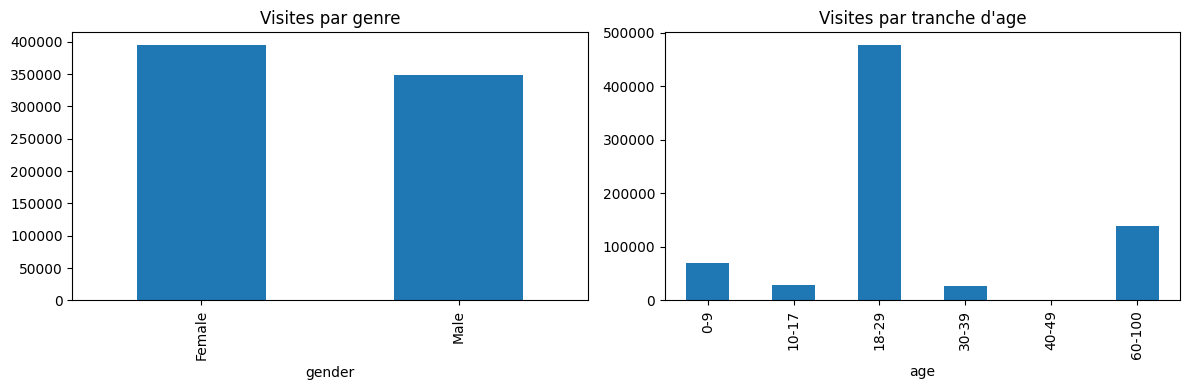

In [147]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))

df.groupby('gender')['Visits'].sum().plot(kind='bar', ax=axes[0], title="Visites par genre")
df.groupby('age')['Visits'].sum().sort_index().plot(kind='bar', ax=axes[1], title="Visites par tranche d'age")

plt.tight_layout()
plt.show()


### 3.10 Comparaison entre les deux caméras

In [148]:
cam_comparison = df.groupby('camera')['Visits'].agg(['sum', 'mean', 'count'])
cam_comparison


,sum,mean,count
camera,,,
Cam_porte1,553845,16.192878,34203
Cam_porte2,190166,7.608162,24995


In [149]:
print(df.groupby('camera')['Visits'].describe())

              count       mean        std  min  25%  50%   75%     max
camera                                                                
Cam_porte1  34203.0  16.192878  21.942831  1.0  3.0  8.0  22.0  1036.0
Cam_porte2  24995.0   7.608162   7.786486  1.0  2.0  5.0  11.0   146.0


### 3.11 Vérification de la cohérence des variables temporelles extraites

In [150]:
print(df[['datetime', 'hour', 'day_of_week', 'month']].head(10))
print(f"Heures conservées : {[int(h) for h in sorted(df['hour'].unique())]}")

             datetime  hour day_of_week    month
0 2025-06-01 09:00:00     9      Sunday  2025-06
1 2025-06-01 09:00:00     9      Sunday  2025-06
2 2025-06-01 09:00:00     9      Sunday  2025-06
3 2025-06-01 09:00:00     9      Sunday  2025-06
4 2025-06-01 09:00:00     9      Sunday  2025-06
5 2025-06-01 09:00:00     9      Sunday  2025-06
6 2025-06-01 09:00:00     9      Sunday  2025-06
7 2025-06-01 09:00:00     9      Sunday  2025-06
8 2025-06-01 10:00:00    10      Sunday  2025-06
9 2025-06-01 10:00:00    10      Sunday  2025-06
Heures conservées : [0, 1, 2, 3, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]


### 3.12 Inspection de la valeur maximale détectée (Visits = 1036)

In [151]:
print(df[df['Visits'] == 1036].to_string())

           camera   datetime  gender  age  Visits        date  hour day_of_week    month
59034  Cam_porte1 2026-05-27  Female  0-9    1036  2026-05-27     0   Wednesday  2026-05


## 4. Préparation des données

### 4.1 Filtrage des heures de nuit (0h–6h)

Les heures 0h à 6h présentent un total de visites quasi nul sur toute la période
et contiennent la valeur aberrante détectée (Visits = 1036 à hour = 0).
Les heures 21h–23h sont conservées car elles peuvent correspondre à des horaires
étendus en période estivale.

À confirmer avec le superviseur : le magasin ferme-t-il systématiquement avant 7h ?

In [152]:
OPENING_HOURS = range(7, 24)  # Supprime uniquement 0h–6h

df = df[df['hour'].isin(OPENING_HOURS)].reset_index(drop=True)

print(f"Lignes après filtrage heures de nuit : {len(df)}")
print(f"Heures conservées : {[int(h) for h in sorted(df['hour'].unique())]}")

Lignes après filtrage heures de nuit : 59086
Heures conservées : [7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]


### 4.2 Détection des valeurs aberrantes — variable `Visits`

`Visits` est un comptage horaire de visiteurs. On applique deux méthodes complémentaires :
- **IQR (Interquartile Range)** : détecte les outliers par rapport à la distribution globale
- **Z-score** : détecte les valeurs statistiquement extrêmes (> 3 écarts-types)

Les visualisations (boxplot, distribution, évolution temporelle) sont regroupées pour
identifier la nature des pics — erreur de capteur ou vraie heure de forte affluence.

Seuil IQR supérieur : 37.0
Outliers détectés (IQR)    : 4467 lignes (7.56%)
Outliers détectés (Z-score): 1277 lignes (2.16%)


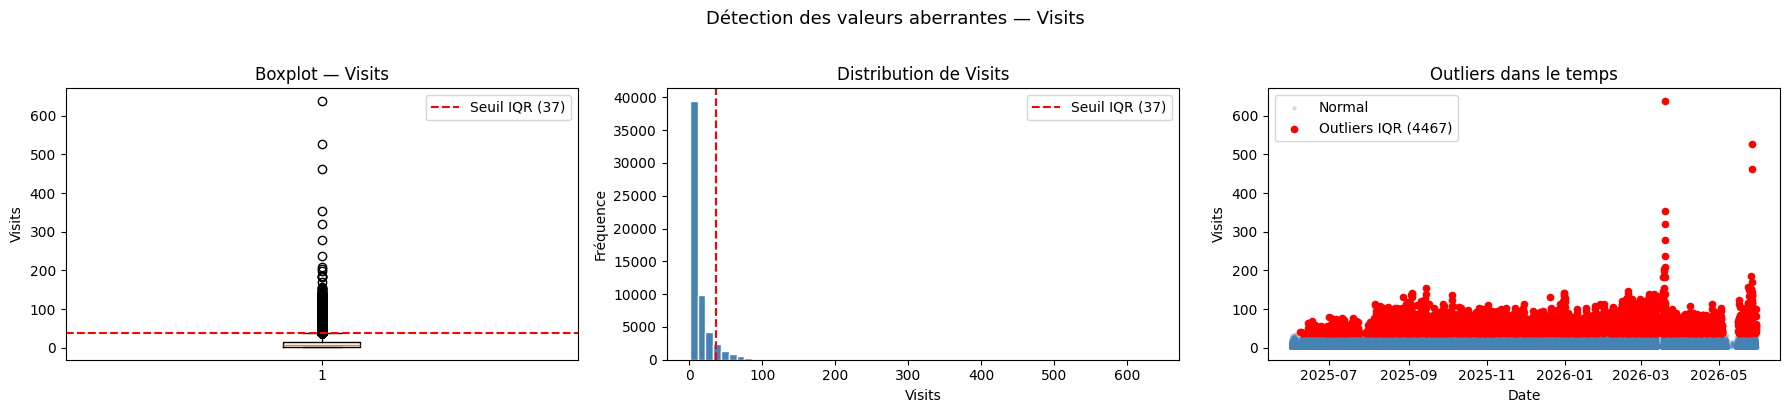

In [153]:
from scipy import stats

# --- Calcul IQR ---
Q1 = df['Visits'].quantile(0.25)
Q3 = df['Visits'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers_iqr = df[df['Visits'] > upper]

# --- Calcul Z-score ---
df['zscore'] = np.abs(stats.zscore(df['Visits']))
outliers_z = df[df['zscore'] > 3]

print(f"Seuil IQR supérieur : {upper:.1f}")
print(f"Outliers détectés (IQR)    : {len(outliers_iqr)} lignes ({len(outliers_iqr)/len(df)*100:.2f}%)")
print(f"Outliers détectés (Z-score): {len(outliers_z)} lignes ({len(outliers_z)/len(df)*100:.2f}%)")

# --- Visualisations regroupées ---
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# 1. Boxplot
axes[0].boxplot(df['Visits'], vert=True)
axes[0].axhline(upper, color='red', linestyle='--', label=f'Seuil IQR ({upper:.0f})')
axes[0].set_title("Boxplot — Visits")
axes[0].set_ylabel("Visits")
axes[0].legend()

# 2. Distribution avec seuil
axes[1].hist(df['Visits'], bins=60, color='steelblue', edgecolor='white')
axes[1].axvline(upper, color='red', linestyle='--', label=f'Seuil IQR ({upper:.0f})')
axes[1].set_title("Distribution de Visits")
axes[1].set_xlabel("Visits")
axes[1].set_ylabel("Fréquence")
axes[1].legend()

# 3. Scatter temporel pour voir où tombent les outliers
axes[2].scatter(df['datetime'], df['Visits'], alpha=0.2, s=5, color='steelblue', label='Normal')
axes[2].scatter(outliers_iqr['datetime'], outliers_iqr['Visits'],
                color='red', s=20, label=f'Outliers IQR ({len(outliers_iqr)})')
axes[2].set_title("Outliers dans le temps")
axes[2].set_xlabel("Date")
axes[2].set_ylabel("Visits")
axes[2].legend()

plt.suptitle("Détection des valeurs aberrantes — Visits", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()



### 4.6 Skeleton-fill — Grille complète caméra × date × heure × genre × âge

Les caméras n'enregistrent une ligne que lorsqu'au moins un visiteur est détecté.
Les combinaisons absentes ne sont donc pas des données manquantes mais des **vrais zéros**.

On construit une grille exhaustive de toutes les combinaisons possibles sur les heures actives
(heures où la caméra fonctionnait), et on remplit les combinaisons absentes avec `Visits = 0`.
Les heures de panne caméra (jours identifiés en 3.4–3.5) restent exclues de ce fill.

In [154]:
from itertools import product

# Heures actives = heures présentes dans le dataset (caméra fonctionnait)
active_hours = df.groupby('camera')['hour'].unique()

cameras   = df['camera'].cat.categories.tolist()
dates     = df['date'].unique()
genders   = df['gender'].cat.categories.tolist()
ages      = df['age'].cat.categories.tolist()

# Construction de la grille complète
grid = pd.DataFrame(
    list(product(cameras, dates, df['hour'].unique(), genders, ages)),
    columns=['camera', 'date', 'hour', 'gender', 'age']
)

# Merge avec les données réelles
df_full = grid.merge(
    df[['camera', 'date', 'hour', 'gender', 'age', 'Visits']],
    on=['camera', 'date', 'hour', 'gender', 'age'],
    how='left'
)

# Les combinaisons absentes dans les heures actives = Visits 0
# Les heures de panne (jours manquants identifiés en 3.4) restent NaN
df_full['Visits'] = df_full['Visits'].fillna(0)

print(f"Lignes avant skeleton-fill : {len(df)}")
print(f"Lignes après skeleton-fill : {len(df_full)}")
print(f"Lignes ajoutées (vrais zéros) : {len(df_full) - len(df)}")

Lignes avant skeleton-fill : 59086
Lignes après skeleton-fill : 141583
Lignes ajoutées (vrais zéros) : 82497


### 4.2 Tri du dataframe complet

Après le skeleton-fill, les lignes ne sont pas dans un ordre structuré.
On trie par caméra → date → heure → genre → âge pour faciliter la lecture
et les étapes de prétraitement suivantes.

In [155]:
df_full = df_full.sort_values(
    ['camera', 'date', 'hour', 'gender', 'age']
).reset_index(drop=True)

df_full.head(20)

,camera,date,hour,gender,age,Visits
0,Cam_porte1,2025-06-01,7,Female,0-9,0.0
1,Cam_porte1,2025-06-01,7,Female,10-17,0.0
2,Cam_porte1,2025-06-01,7,Female,18-29,0.0
3,Cam_porte1,2025-06-01,7,Female,30-39,0.0
4,Cam_porte1,2025-06-01,7,Female,40-49,0.0
5,Cam_porte1,2025-06-01,7,Female,60-100,0.0
6,Cam_porte1,2025-06-01,7,Male,0-9,0.0
7,Cam_porte1,2025-06-01,7,Male,10-17,0.0
8,Cam_porte1,2025-06-01,7,Male,18-29,0.0
9,Cam_porte1,2025-06-01,7,Male,30-39,0.0


### 4.3 Vérification du skeleton-fill

On s'assure que les lignes ajoutées (vrais zéros) sont bien distinctes
des lignes réelles, et que le merge s'est déroulé correctement.

In [156]:
# Lignes réelles (Visits > 0)
print("Exemple lignes réelles :")
print(df_full[df_full['Visits'] > 0].head(5).to_string())

print("\nExemple lignes ajoutées (vrais zéros) :")
print(df_full[df_full['Visits'] == 0].head(5).to_string())

Exemple lignes réelles :
        camera        date  hour  gender     age  Visits
24  Cam_porte1  2025-06-01     9  Female     0-9     1.0
25  Cam_porte1  2025-06-01     9  Female   10-17     1.0
26  Cam_porte1  2025-06-01     9  Female   18-29     1.0
27  Cam_porte1  2025-06-01     9  Female   30-39     1.0
29  Cam_porte1  2025-06-01     9  Female  60-100     1.0

Exemple lignes ajoutées (vrais zéros) :
       camera        date  hour  gender    age  Visits
0  Cam_porte1  2025-06-01     7  Female    0-9     0.0
1  Cam_porte1  2025-06-01     7  Female  10-17     0.0
2  Cam_porte1  2025-06-01     7  Female  18-29     0.0
3  Cam_porte1  2025-06-01     7  Female  30-39     0.0
4  Cam_porte1  2025-06-01     7  Female  40-49     0.0


## 5. Flagging — Classification des jours et enrichissement calendaire

Cette section attribue à chaque jour un statut (`day_status`) et enrichit le dataset
avec des indicateurs liés aux jours fériés, vacances scolaires et effets pré/post-férié.
Ces flags seront des features essentielles pour le modèle ML.

**Catégories `day_status` :**

| Valeur | Signification |
|---|---|
| `normal` | Données complètes et fiables |
| `holiday` | Jour férié officiel — magasin fermé (aucune donnée attendue) |
| `camera_breakdown` | Une caméra absente — comptage partiel, données non fiables |
| `anomaly` | Les deux caméras présentes mais visites < 30% de la médiane du jour de la semaine — cause inconnue (fermeture ponctuelle, fin de dataset...) |

> ⚠️ Les jours `camera_breakdown` et `anomaly` doivent être **exclus ou imputés** avant modélisation.

In [157]:
import holidays as hol_lib

# ── 5.1  Bibliothèque des jours fériés tunisiens ────────────────────────────
tn_holidays = {}
for year in [2025, 2026]:
    for date, name in hol_lib.Tunisia(years=year).items():
        tn_holidays[date] = name

print(f"Jours fériés chargés : {len(tn_holidays)}")
for d, n in sorted(tn_holidays.items()):
    print(f"  {d}  ({d.strftime('%A')[:3]})  {n}")

Jours fériés chargés : 33
  2025-01-01  (Wed)  New Year's Day
  2025-01-14  (Tue)  Revolution and Youth Day
  2025-03-20  (Thu)  Independence Day
  2025-03-30  (Sun)  Eid al-Fitr (estimated)
  2025-03-31  (Mon)  Eid al-Fitr Holiday (estimated)
  2025-04-01  (Tue)  Eid al-Fitr Holiday (estimated)
  2025-04-09  (Wed)  Martyrs' Day
  2025-05-01  (Thu)  Labor Day
  2025-06-05  (Thu)  Arafat Day (estimated)
  2025-06-06  (Fri)  Eid al-Adha (estimated)
  2025-06-07  (Sat)  Eid al-Adha Holiday (estimated)
  2025-06-08  (Sun)  Eid al-Adha Holiday (estimated)
  2025-06-26  (Thu)  Islamic New Year (estimated)
  2025-07-25  (Fri)  Republic Day
  2025-08-13  (Wed)  Women's Day
  2025-09-04  (Thu)  Prophet's Birthday (estimated)
  2025-10-15  (Wed)  Evacuation Day
  2026-01-01  (Thu)  New Year's Day
  2026-01-14  (Wed)  Revolution and Youth Day
  2026-03-20  (Fri)  Eid al-Fitr (estimated); Independence Day
  2026-03-21  (Sat)  Eid al-Fitr Holiday (estimated)
  2026-03-22  (Sun)  Eid al-Fitr Holiday

### 5.2 Vacances scolaires tunisiennes (2025-2026)

Ces périodes ne figurent pas dans la bibliothèque `holidays` mais ont un impact
direct sur la fréquentation. Source : calendrier scolaire officiel Tunisie 2025-2026.

In [158]:
# ── 5.2  Vacances scolaires tunisiennes 2025-2026 ──────────────────────────
SCHOOL_HOLIDAYS = [
    # (debut, fin, label)
    ('2025-10-25', '2025-11-03', 'Vacances automne'),
    ('2025-12-25', '2026-01-05', 'Vacances hiver'),
    ('2026-03-14', '2026-03-22', 'Vacances printemps'),
    ('2026-06-13', '2026-09-13', 'Grandes vacances'),
]

school_holiday_dates = set()
for start, end, label in SCHOOL_HOLIDAYS:
    for d in pd.date_range(start, end, freq='D'):
        school_holiday_dates.add(d.date())

print(f"Jours de vacances scolaires couverts : {len(school_holiday_dates)}")

Jours de vacances scolaires couverts : 124


### 5.3 Construction du résumé journalier

On agrège les données au niveau du jour pour calculer les seuils d'anomalie
et attribuer un statut à chaque date.

In [159]:
# ── 5.3  Résumé journalier ──────────────────────────────────────────────────
daily_total = df_full.groupby('date')['Visits'].sum()
daily_total.index = pd.to_datetime(daily_total.index)

# Visites par caméra par jour (pour détecter les pannes)
daily_cams = (
    df_full.groupby(['date', 'camera'])['Visits']
    .sum()
    .unstack(fill_value=0)
)
daily_cams.index = pd.to_datetime(daily_cams.index)

# Médiane des visites par jour de la semaine
dow_medians = daily_total.groupby(daily_total.index.dayofweek).median()

print('Médiane des visites par jour de la semaine :')
days_fr = ['Lundi','Mardi','Mercredi','Jeudi','Vendredi','Samedi','Dimanche']
for i, label in enumerate(days_fr):
    print(f'  {label}: {dow_medians[i]:.0f} visites')

Médiane des visites par jour de la semaine :
  Lundi: 1992 visites
  Mardi: 2090 visites
  Mercredi: 2170 visites
  Jeudi: 1992 visites
  Vendredi: 2102 visites
  Samedi: 2545 visites
  Dimanche: 2276 visites


### 5.4 Attribution du statut `day_status`

**Priorité d'attribution (ordre strict) :**
1. `holiday` — jour dans `holidays.Tunisia`
2. `camera_breakdown` — au moins une caméra avec 0 visites
3. `anomaly` — les deux caméras actives mais total < 30% de la médiane du jour de la semaine
4. `normal` — tout le reste

In [160]:
# ── 5.4  Attribution day_status ────────────────────────────────────────────
ANOMALY_THRESHOLD = 0.30  # < 30% de la médiane du jour de la semaine

def classify_day(date_ts, total_visits, cam_row):
    d = date_ts.date()
    dow = date_ts.dayofweek
    threshold = dow_medians[dow] * ANOMALY_THRESHOLD

    if d in tn_holidays:
        return 'holiday'

    cam_values = cam_row.values if cam_row is not None else []
    if any(v == 0 for v in cam_values):
        return 'camera_breakdown'

    if total_visits < threshold:
        return 'anomaly'

    return 'normal'

status_records = []
for date_ts, total in daily_total.items():
    cam_row = daily_cams.loc[date_ts] if date_ts in daily_cams.index else None
    status = classify_day(date_ts, total, cam_row)
    status_records.append({'date': date_ts.date(), 'day_status': status})

day_status_df = pd.DataFrame(status_records)

print('Répartition des statuts :')
print(day_status_df['day_status'].value_counts())
print()
print('Détail des jours non-normaux :')
non_normal = day_status_df[day_status_df['day_status'] != 'normal'].copy()
non_normal['dow'] = pd.to_datetime(non_normal['date']).dt.day_name()
non_normal['total_visits'] = non_normal['date'].map(
    lambda d: daily_total.get(pd.Timestamp(d), 0)
)
print(non_normal.to_string(index=False))

Répartition des statuts :
day_status
normal              322
holiday              14
camera_breakdown      6
anomaly               5
Name: count, dtype: int64

Détail des jours non-normaux :
      date       day_status       dow  total_visits
2025-06-05          holiday  Thursday        1334.0
2025-06-08          holiday    Sunday         725.0
2025-06-26          holiday  Thursday        1794.0
2025-07-25          holiday    Friday        1208.0
2025-08-10          anomaly    Sunday         386.0
2025-08-13          holiday Wednesday        2463.0
2025-09-04          holiday  Thursday        1527.0
2025-10-15          holiday Wednesday        2197.0
2025-11-13          anomaly  Thursday         420.0
2025-12-11          anomaly  Thursday         181.0
2026-01-01          holiday  Thursday        1464.0
2026-01-14          holiday Wednesday        2175.0
2026-01-27          anomaly   Tuesday         274.0
2026-03-22          holiday    Sunday        1539.0
2026-04-09          holiday  

### 5.5 Flags pré-férié et post-férié

L'analyse des données révèle un effet très fort la veille des grands jours fériés :

| Férié | Visites J-1 | vs médiane |
|---|---|---|
| Aïd al-Fitr (mars 2026) | ~7 088 | **+229%** |
| Aïd al-Adha (mai 2026) | ~6 193 | **+187%** |
| Mawlid (sept 2025) | ~3 469 | +61% |

**Flags créés :**
- `is_pre_holiday` : 1 si le lendemain est un jour férié (J-1)
- `is_post_holiday` : 1 si la veille était un jour férié (J+1)
- `pre_holiday_name` : nom du férié (l'effet varie selon le type de fête)
- `days_to_next_holiday` / `days_since_last_holiday` : versions continues pour capturer l'effet décroissant

In [161]:
# ── 5.5  Flags pré/post-férié ───────────────────────────────────────────────
import datetime

all_holiday_dates = sorted(tn_holidays.keys())

def days_to_next_hol(d):
    future = [h for h in all_holiday_dates if h > d]
    return (future[0] - d).days if future else None

def days_since_last_hol(d):
    past = [h for h in all_holiday_dates if h < d]
    return (d - past[-1]).days if past else None

def pre_holiday_name(d):
    next_day = d.date() + datetime.timedelta(days=1)
    return tn_holidays.get(next_day, None)

day_status_df['date'] = pd.to_datetime(day_status_df['date'])
day_status_df['days_to_next_holiday']   = day_status_df['date'].apply(lambda d: days_to_next_hol(d.date()))
day_status_df['days_since_last_holiday'] = day_status_df['date'].apply(lambda d: days_since_last_hol(d.date()))
day_status_df['is_pre_holiday']          = (day_status_df['days_to_next_holiday'] == 1).astype(int)
day_status_df['is_post_holiday']         = (day_status_df['days_since_last_holiday'] == 1).astype(int)
day_status_df['pre_holiday_name']        = day_status_df['date'].apply(pre_holiday_name)

# Aperçu avec visites réelles
pre_hol = day_status_df[day_status_df['is_pre_holiday'] == 1].copy()
pre_hol['total_visits'] = pre_hol['date'].map(lambda d: daily_total.get(pd.Timestamp(d), None))
median_overall = daily_total.median()
pre_hol['vs_median_%'] = ((pre_hol['total_visits'] / median_overall - 1) * 100).round(1)

print('Jours pré-fériés présents dans le dataset :')
print(pre_hol[['date','pre_holiday_name','total_visits','vs_median_%']].to_string(index=False))

Jours pré-fériés présents dans le dataset :
      date                          pre_holiday_name  total_visits  vs_median_%
2025-06-04                    Arafat Day (estimated)        1107.0        -48.6
2025-06-05                   Eid al-Adha (estimated)        1334.0        -38.1
2025-06-25              Islamic New Year (estimated)        1898.0        -11.9
2025-07-24                              Republic Day        1510.0        -29.9
2025-08-12                               Women's Day        2483.0         15.3
2025-09-03            Prophet's Birthday (estimated)        3469.0         61.0
2025-10-14                            Evacuation Day        1961.0         -9.0
2025-12-31                            New Year's Day        3422.0         58.9
2026-03-19 Eid al-Fitr (estimated); Independence Day        6902.0        220.4
2026-04-08                              Martyrs' Day        2188.0          1.6
2026-04-30                                 Labor Day        2026.0         -

### 5.6 Flag vacances scolaires

Indicateur booléen `is_school_holiday` pour chaque jour du dataset.

In [162]:
# ── 5.6  Flag vacances scolaires ────────────────────────────────────────────
day_status_df['is_school_holiday'] = day_status_df['date'].apply(
    lambda d: int(d.date() in school_holiday_dates)
)

print(f"Jours de vacances scolaires dans le dataset : {day_status_df['is_school_holiday'].sum()}")
print()
print('Récapitulatif global des flags :')
print(day_status_df[['is_pre_holiday','is_post_holiday','is_school_holiday']].sum().rename('nb_jours'))

Jours de vacances scolaires dans le dataset : 26

Récapitulatif global des flags :
is_pre_holiday       13
is_post_holiday      15
is_school_holiday    26
Name: nb_jours, dtype: int64


### 5.7 Jointure des flags sur le dataset principal

On joint tous les flags journaliers sur `df_full` (granularité horaire × caméra × genre × âge).

In [163]:
# ── 5.7  Jointure sur df_full ───────────────────────────────────────────────
df_full['date'] = pd.to_datetime(df_full['date'])

flag_cols = ['date','day_status','is_pre_holiday','is_post_holiday',
             'pre_holiday_name','days_to_next_holiday','days_since_last_holiday',
             'is_school_holiday']

df_full = df_full.merge(day_status_df[flag_cols], on='date', how='left')

print('Colonnes ajoutées :', [c for c in flag_cols if c != 'date'])
print(f'Shape df_full : {df_full.shape}')
print()
print('Exemple — jours pré-fériés dans df_full :')
sample_cols = ['date','hour','camera','gender','age','Visits','day_status','pre_holiday_name']
print(df_full[df_full['is_pre_holiday']==1][sample_cols].head(10).to_string(index=False))

Colonnes ajoutées : ['day_status', 'is_pre_holiday', 'is_post_holiday', 'pre_holiday_name', 'days_to_next_holiday', 'days_since_last_holiday', 'is_school_holiday']
Shape df_full : (141583, 13)

Exemple — jours pré-fériés dans df_full :
      date  hour     camera gender    age  Visits day_status       pre_holiday_name
2025-06-04     7 Cam_porte1 Female    0-9     0.0     normal Arafat Day (estimated)
2025-06-04     7 Cam_porte1 Female  10-17     0.0     normal Arafat Day (estimated)
2025-06-04     7 Cam_porte1 Female  18-29     0.0     normal Arafat Day (estimated)
2025-06-04     7 Cam_porte1 Female  30-39     0.0     normal Arafat Day (estimated)
2025-06-04     7 Cam_porte1 Female  40-49     0.0     normal Arafat Day (estimated)
2025-06-04     7 Cam_porte1 Female 60-100     0.0     normal Arafat Day (estimated)
2025-06-04     7 Cam_porte1   Male    0-9     0.0     normal Arafat Day (estimated)
2025-06-04     7 Cam_porte1   Male  10-17     0.0     normal Arafat Day (estimated)
2025-06-

## 5.8 Météo réelle — Open-Meteo (Sfax)

On enrichit le dataset avec la météo historique réelle via l'API gratuite
[Open-Meteo](https://open-meteo.com/) — aucune clé API requise.

**Coordonnées Sfax** : latitude=34.74, longitude=10.76, fuseau Africa/Tunis

La météo est une variable **journalière** : on la récupère une fois par jour
puis on la joint sur toutes les lignes de `df_full` (qui est à granularité
horaire × caméra × genre × âge).

**Variables récupérées :**

| Colonne | Description |
|---|---|
| `temp_max_c` | Température maximale du jour (°C) |
| `temp_min_c` | Température minimale du jour (°C) |
| `temp_range_c` | Écart thermique max–min (°C) |
| `precipitation_mm` | Cumul de précipitations (mm) |
| `wind_kmh` | Vitesse max du vent (km/h) |
| `humidity_pct` | Humidité relative maximale (%) |
| `is_rainy` | 1 si précipitations > 0.5 mm |
| `heat_stress` | 1 si temp max > 38°C (chaleur extrême à Sfax) |
| `weather_comfort_score` | Score synthétique 0–10 (10 = conditions idéales pour sortir) |

> ⚠️ Les colonnes météo seront `NaN` pour les jours sans données (jours fériés,
> pannes caméra) — c'est normal, ces jours sont déjà exclus du dataset de modélisation.

In [164]:
# ── 5.8  Météo réelle Open-Meteo ─────────────────────────────────────────────
import requests

def fetch_weather_sfax(start_date: str, end_date: str) -> pd.DataFrame:
    """
    Récupère la météo historique journalière pour Sfax via Open-Meteo Archive API.
    start_date / end_date : format 'YYYY-MM-DD'
    Retourne un DataFrame avec une ligne par jour.
    """
    url = (
        "https://archive-api.open-meteo.com/v1/archive"
        "?latitude=34.74&longitude=10.76"
        f"&start_date={start_date}&end_date={end_date}"
        "&daily=temperature_2m_max,temperature_2m_min,"
        "precipitation_sum,windspeed_10m_max,relative_humidity_2m_max"
        "&timezone=Africa%2FTunis"
    )
    r = requests.get(url, timeout=30)
    r.raise_for_status()

    raw = r.json()['daily']
    df_w = pd.DataFrame({
        'date':             pd.to_datetime(raw['time']),
        'temp_max_c':       raw['temperature_2m_max'],
        'temp_min_c':       raw['temperature_2m_min'],
        'precipitation_mm': raw['precipitation_sum'],
        'wind_kmh':         raw['windspeed_10m_max'],
        'humidity_pct':     raw['relative_humidity_2m_max'],
    })
    return df_w

# Récupération sur toute la période du dataset
start = df_full['date'].min().strftime('%Y-%m-%d')
end   = df_full['date'].max().strftime('%Y-%m-%d')

print(f"Téléchargement météo Sfax : {start} → {end} ...")
df_weather = fetch_weather_sfax(start, end)
print(f"Météo récupérée : {len(df_weather)} jours ✅")
print()
print(df_weather.describe().round(1))

Téléchargement météo Sfax : 2025-06-01 → 2026-05-30 ...
Météo récupérée : 364 jours ✅

                      date  temp_max_c  temp_min_c  precipitation_mm  \
count                  364       364.0       364.0             364.0   
mean   2025-11-29 12:00:00        25.5        16.7               0.8   
min    2025-06-01 00:00:00        12.3         3.2               0.0   
25%    2025-08-30 18:00:00        19.5        11.6               0.0   
50%    2025-11-29 12:00:00        25.8        16.5               0.0   
75%    2026-02-28 06:00:00        31.5        22.0               0.1   
max    2026-05-30 00:00:00        42.7        28.2              59.5   
std                    NaN         6.5         5.8               3.7   

       wind_kmh  humidity_pct  
count     364.0         364.0  
mean       17.0          82.2  
min         8.0          37.0  
25%        13.5          75.0  
50%        15.7          83.0  
75%        19.5          91.0  
max        35.9         100.0  
std     

In [165]:
# ── Features météo dérivées ───────────────────────────────────────────────────

# Écart thermique
df_weather['temp_range_c'] = (df_weather['temp_max_c'] - df_weather['temp_min_c']).round(1)

# Chaleur extrême (seuil Sfax : 38°C)
df_weather['heat_stress'] = (df_weather['temp_max_c'] > 38).astype(int)

# Pluie binaire
df_weather['is_rainy'] = (df_weather['precipitation_mm'] > 0.5).astype(int)

# Score de confort météo (0 = mauvais, 10 = idéal pour sortir)
def comfort_score(row):
    if pd.isna(row['temp_max_c']):
        return np.nan
    score = 10.0
    # Pénalité chaleur
    if   row['temp_max_c'] > 38: score -= 4.0
    elif row['temp_max_c'] > 33: score -= 2.0
    elif row['temp_max_c'] > 30: score -= 1.0
    # Pénalité froid
    if   row['temp_max_c'] < 10: score -= 3.0
    elif row['temp_max_c'] < 15: score -= 1.5
    # Pénalité pluie
    if   row['precipitation_mm'] > 5:   score -= 3.5
    elif row['precipitation_mm'] > 1:   score -= 1.5
    elif row['precipitation_mm'] > 0.3: score -= 0.5
    # Pénalité vent
    if   row['wind_kmh'] > 50: score -= 2.0
    elif row['wind_kmh'] > 40: score -= 1.0
    # Humidité + chaleur combinées
    if row['temp_max_c'] > 28 and row['humidity_pct'] > 70:
        score -= 1.0
    return round(max(0.0, min(10.0, score)), 1)

df_weather['weather_comfort_score'] = df_weather.apply(comfort_score, axis=1)

# ── Jointure sur df_full (granularité horaire) ────────────────────────────────
weather_cols = [
    'date', 'temp_max_c', 'temp_min_c', 'temp_range_c',
    'precipitation_mm', 'wind_kmh', 'humidity_pct',
    'is_rainy', 'heat_stress', 'weather_comfort_score'
]

df_full = df_full.merge(df_weather[weather_cols], on='date', how='left')

print("Météo jointe sur df_full ✅")
print(f"Shape df_full : {df_full.shape}")
print()
print("Vérification — NaN météo attendus uniquement sur jours fériés/pannes :")
missing_weather = df_full[df_full['temp_max_c'].isna()]['date'].nunique()
print(f"  Jours sans météo : {missing_weather}")
print()
print("Exemple — journées chaudes (heat_stress=1) :")
hot_days = df_full[df_full['heat_stress']==1][
    ['date','temp_max_c','humidity_pct','weather_comfort_score']
].drop_duplicates('date')
print(hot_days.to_string(index=False))

Météo jointe sur df_full ✅
Shape df_full : (141583, 22)

Vérification — NaN météo attendus uniquement sur jours fériés/pannes :
  Jours sans météo : 0

Exemple — journées chaudes (heat_stress=1) :
      date  temp_max_c  humidity_pct  weather_comfort_score
2025-07-08        38.2            67                    6.0
2025-07-14        41.3            75                    5.0
2025-07-21        41.8            72                    5.0
2025-07-24        42.7            75                    5.0
2025-07-25        39.4            72                    5.0
2025-08-28        38.8            86                    5.0


## 6. Export du dataset nettoyé

Le dataset est maintenant :
- ✅ Normalisé (camera, gender, age — formats unifiés)
- ✅ Sans doublons
- ✅ Filtré (heures de nuit 0h–6h supprimées)
- ✅ Skeleton-fill appliqué (vrais zéros explicites)
- ✅ Enrichi : `day_status`, flags pré/post-férié, vacances scolaires

**Deux fichiers exportés :**
1. `shoppingclub_cleaned_full.csv` — dataset complet (tous statuts) → pour audit et analyse
2. `shoppingclub_cleaned_model_ready.csv` — jours `normal` uniquement → prêt pour le modèle ML

In [166]:
# ── 6.1  Export dataset complet ─────────────────────────────────────────────
output_full = '/content/shoppingclub_cleaned_full.csv'
df_full.to_csv(output_full, index=False)

print(f'Dataset complet exporté -> {output_full}')
print(f'Shape : {df_full.shape}')
print(f'Colonnes : {df_full.columns.tolist()}')

Dataset complet exporté -> /content/shoppingclub_cleaned_full.csv
Shape : (141583, 22)
Colonnes : ['camera', 'date', 'hour', 'gender', 'age', 'Visits', 'day_status', 'is_pre_holiday', 'is_post_holiday', 'pre_holiday_name', 'days_to_next_holiday', 'days_since_last_holiday', 'is_school_holiday', 'temp_max_c', 'temp_min_c', 'temp_range_c', 'precipitation_mm', 'wind_kmh', 'humidity_pct', 'is_rainy', 'heat_stress', 'weather_comfort_score']


In [167]:
# Exclude days with missing or unreliable camera data
EXCLUDE_STATUSES = ['holiday', 'camera_breakdown', 'anomaly_unknown']

df_model = df_full[
    ~df_full['day_status'].isin(EXCLUDE_STATUSES)
].copy()

print(f"Dataset modélisation : {df_model['date'].nunique()} jours conservés")
print()
print("Jours exclus :")
excluded = df_full[df_full['day_status'].isin(EXCLUDE_STATUSES)]
print(excluded.drop_duplicates('date')[['date','day_status']].to_string(index=False))
print()
print("Répartition des statuts conservés :")
print(df_model.drop_duplicates('date')['day_status'].value_counts())

Dataset modélisation : 327 jours conservés

Jours exclus :
      date       day_status
2025-06-05          holiday
2025-06-08          holiday
2025-06-26          holiday
2025-07-25          holiday
2025-08-13          holiday
2025-09-04          holiday
2025-10-15          holiday
2026-01-01          holiday
2026-01-14          holiday
2026-03-22          holiday
2026-04-09          holiday
2026-05-01          holiday
2026-05-05 camera_breakdown
2026-05-06 camera_breakdown
2026-05-07 camera_breakdown
2026-05-08 camera_breakdown
2026-05-11 camera_breakdown
2026-05-14 camera_breakdown
2026-05-26          holiday
2026-05-29          holiday

Répartition des statuts conservés :
day_status
normal     322
anomaly      5
Name: count, dtype: int64


In [168]:
# ── 6.1  Export dataset de modélisation ─────────────────────────────────────────────
output_full = '/content/shoppingclub_cleaned_model_ready.csv'
df_model.to_csv(output_full, index=False)

print(f'Dataset complet exporté -> {output_full}')
print(f'Shape : {df_full.shape}')
print(f'Colonnes : {df_full.columns.tolist()}')

Dataset complet exporté -> /content/shoppingclub_cleaned_model_ready.csv
Shape : (141583, 22)
Colonnes : ['camera', 'date', 'hour', 'gender', 'age', 'Visits', 'day_status', 'is_pre_holiday', 'is_post_holiday', 'pre_holiday_name', 'days_to_next_holiday', 'days_since_last_holiday', 'is_school_holiday', 'temp_max_c', 'temp_min_c', 'temp_range_c', 'precipitation_mm', 'wind_kmh', 'humidity_pct', 'is_rainy', 'heat_stress', 'weather_comfort_score']


In [169]:
# ── 6.3  Aperçu final du dataset de modélisation ────────────────────────────
print('Premières lignes (df_model) :')
print(df_model.head(10).to_string(index=False))
print()
print('Types des colonnes :')
print(df_model.dtypes)

Premières lignes (df_model) :
    camera       date  hour gender    age  Visits day_status  is_pre_holiday  is_post_holiday pre_holiday_name  days_to_next_holiday  days_since_last_holiday  is_school_holiday  temp_max_c  temp_min_c  temp_range_c  precipitation_mm  wind_kmh  humidity_pct  is_rainy  heat_stress  weather_comfort_score
Cam_porte1 2025-06-01     7 Female    0-9     0.0     normal               0                0             None                     4                       31                  0        25.9        17.9           8.0               0.0      14.0            76         0            0                   10.0
Cam_porte1 2025-06-01     7 Female  10-17     0.0     normal               0                0             None                     4                       31                  0        25.9        17.9           8.0               0.0      14.0            76         0            0                   10.0
Cam_porte1 2025-06-01     7 Female  18-29     0.0     normal 

In [170]:
from google.colab import files

files.download('/content/shoppingclub_cleaned_full.csv')
files.download('/content/shoppingclub_cleaned_model_ready.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>